# ImageCLEF GANs 2026 – Task 1: V4 Enhanced MIA



In [ ]:
# !pip install -q timm scikit-learn scikit-image pandas matplotlib pillow tqdm scipy

In [ ]:
import os, gc, json, shutil, random, warnings, pickle
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    cohen_kappa_score, balanced_accuracy_score, accuracy_score,
    precision_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    ExtraTreesClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier, RandomForestClassifier
)
from skimage.metrics import structural_similarity as ssim
from skimage.feature import local_binary_pattern
from scipy.stats import kurtosis, skew, entropy as sp_entropy
from scipy.spatial.distance import cdist
from scipy.fft import fft2, fftshift

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tvm
import timm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
print(f"DEVICE: {DEVICE}")

DEVICE: mps


In [ ]:
# ── Paths ──
ROOT = Path.home() / "Desktop" / "GAN"
TRAIN_ROOT = ROOT / "ImageCLEF_GANs2026_Detect_training_"
TEST_ROOT  = ROOT / "ImageCLEF_GANs2026_Detect_training_dev"

if not TRAIN_ROOT.exists():
    cands = [p for p in ROOT.glob("*Detect_training*") if p.is_dir() and "dev" not in p.name.lower()]
    if cands: TRAIN_ROOT = cands[0]
if not TEST_ROOT.exists():
    cands = [p for p in ROOT.glob("*Detect_training*") if p.is_dir() and "dev" in p.name.lower()]
    if cands: TEST_ROOT = cands[0]

GENERATED_DIR     = TRAIN_ROOT / "generated"
REAL_USED_DIR     = TRAIN_ROOT / "real_used"
REAL_NOT_USED_DIR = TRAIN_ROOT / "real_not_used"
REAL_UNKNOWN_DIR  = TEST_ROOT  / "real_unknown"

for d in [GENERATED_DIR, REAL_USED_DIR, REAL_NOT_USED_DIR, REAL_UNKNOWN_DIR]:
    assert d.exists(), f"Missing: {d}"

RUN_NAME = "task1_v4_enhanced"
OUT_DIR     = ROOT / RUN_NAME
RESULTS_DIR = OUT_DIR / "results"
FIG_DIR     = OUT_DIR / "figures"
PRED_DIR    = OUT_DIR / "predictions"
CACHE_DIR   = OUT_DIR / "cache"
CKPT_DIR    = OUT_DIR / "checkpoints"

for d in [OUT_DIR, RESULTS_DIR, FIG_DIR, PRED_DIR, CACHE_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def save_json(obj, path):
    with open(path, "w") as f: json.dump(obj, f, indent=2)

def list_pngs(folder):
    return sorted(folder.glob("*.png"))

In [ ]:
# ── DataFrames ──
generated_paths  = list(list_pngs(GENERATED_DIR))
used_paths       = list(list_pngs(REAL_USED_DIR))
not_used_paths   = list(list_pngs(REAL_NOT_USED_DIR))
unknown_paths    = list(list_pngs(REAL_UNKNOWN_DIR))

print(f"generated={len(generated_paths)}, used={len(used_paths)}, "
      f"not_used={len(not_used_paths)}, unknown={len(unknown_paths)}")

train_df = pd.DataFrame({
    "image_id":   [p.name for p in used_paths + not_used_paths],
    "image_path": [str(p) for p in used_paths + not_used_paths],
    "label":      [1]*len(used_paths) + [0]*len(not_used_paths)
}).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_df = pd.DataFrame({
    "image_id":   [p.name for p in unknown_paths],
    "image_path": [str(p) for p in unknown_paths]
})

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

generated=10000, used=3200, not_used=3200, unknown=2140
Train: 6400 | Test: 2140


In [ ]:
IMG_SIZE = 256

def load_gray_np(path, size=IMG_SIZE):
    img = Image.open(path).convert("L").resize((size, size), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

# Pre-load generated images
gen_cache = CACHE_DIR / "generated_arrays.npy"
if gen_cache.exists():
    print("Loading cached generated arrays...")
    gen_arrays = np.load(gen_cache)
else:
    print("Loading all generated images...")
    gen_arrays = np.stack([load_gray_np(p) for p in tqdm(generated_paths)])
    np.save(gen_cache, gen_arrays)
print(f"Generated bank: {gen_arrays.shape} ({gen_arrays.nbytes/1e6:.0f} MB)")

Loading all generated images...


100%|██████████| 10000/10000 [00:06<00:00, 1530.74it/s]


Generated bank: (10000, 256, 256) (2621 MB)


---
## NEW Signal 1: Frequency-Domain Features (FFT/DCT Spectral Analysis)

**This is the most important new signal.** GANs produce images with characteristic
spectral artifacts — the frequency spectrum of GAN-generated images differs from
real images in systematic ways. Training images will have spectral profiles that
the GAN learned to reproduce, while non-training images may differ.

We compute:
1. Azimuthally-averaged power spectrum of each image
2. Spectral distance to the mean generated spectrum
3. Spectral residual features (how much the image deviates from "GAN-typical")

In [ ]:
def azimuthal_avg_power_spectrum(img, n_bins=64):
    """Compute azimuthally averaged power spectrum."""
    f = fftshift(fft2(img - img.mean()))
    power = np.abs(f) ** 2
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    max_r = min(cy, cx)
    bin_edges = np.linspace(0, max_r, n_bins + 1).astype(int)
    spectrum = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (r >= bin_edges[i]) & (r < bin_edges[i+1])
        if mask.any():
            spectrum[i] = power[mask].mean()
    # Avoid log(0)
    spectrum = np.log1p(spectrum)
    return spectrum

def compute_spectral_features(img, gen_mean_spectrum, gen_std_spectrum):
    """Compute spectral features for a single image."""
    spec = azimuthal_avg_power_spectrum(img)

    # Distance to mean generated spectrum
    diff = spec - gen_mean_spectrum
    z_score = diff / (gen_std_spectrum + 1e-8)

    feats = {
        # Spectral distance metrics
        "spec_l2_dist":      float(np.sqrt((diff**2).sum())),
        "spec_cos_sim":      float(np.dot(spec, gen_mean_spectrum) /
                                    (np.linalg.norm(spec) * np.linalg.norm(gen_mean_spectrum) + 1e-8)),
        "spec_mae":          float(np.abs(diff).mean()),
        # Z-score stats (how many std away from generated mean)
        "spec_zscore_mean":  float(np.abs(z_score).mean()),
        "spec_zscore_max":   float(np.abs(z_score).max()),
        "spec_zscore_std":   float(z_score.std()),
        # Band-specific features (low/mid/high frequency)
        "spec_low_energy":   float(spec[:16].sum()),     # low freq
        "spec_mid_energy":   float(spec[16:40].sum()),   # mid freq
        "spec_high_energy":  float(spec[40:].sum()),     # high freq
        "spec_low_diff":     float(diff[:16].mean()),
        "spec_mid_diff":     float(diff[16:40].mean()),
        "spec_high_diff":    float(diff[40:].mean()),
        # Spectral shape
        "spec_slope":        float(np.polyfit(np.arange(len(spec)), spec, 1)[0]),
        "spec_curvature":    float(np.diff(spec, n=2).mean()),
        "spec_entropy":      float(sp_entropy(spec / (spec.sum() + 1e-8) + 1e-10)),
        "spec_peak_freq":    float(np.argmax(spec)),
        "spec_total_power":  float(spec.sum()),
    }
    return feats

# Compute mean/std spectrum from generated images
spec_cache = CACHE_DIR / "gen_spectra_stats.npz"
if spec_cache.exists():
    d = np.load(spec_cache)
    gen_mean_spec, gen_std_spec = d["mean"], d["std"]
else:
    print("Computing generated image spectra (sampling 3000)...")
    sample_idx = np.random.RandomState(42).choice(len(gen_arrays), 3000, replace=False)
    gen_spectra = np.stack([azimuthal_avg_power_spectrum(gen_arrays[i]) for i in tqdm(sample_idx)])
    gen_mean_spec = gen_spectra.mean(axis=0)
    gen_std_spec  = gen_spectra.std(axis=0)
    np.savez(spec_cache, mean=gen_mean_spec, std=gen_std_spec)
print(f"Generated spectrum: {gen_mean_spec.shape}")

Computing generated image spectra (sampling 3000)...


100%|██████████| 3000/3000 [00:12<00:00, 243.67it/s]

Generated spectrum: (64,)


In [ ]:
spec_train_cache = CACHE_DIR / "spectral_feats_train.json"
spec_test_cache  = CACHE_DIR / "spectral_feats_test.json"

if spec_train_cache.exists():
    train_spec_feats = json.loads(spec_train_cache.read_text())
    test_spec_feats  = json.loads(spec_test_cache.read_text())
else:
    print("Computing spectral features...")
    train_spec_feats = []
    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Train spectra"):
        img = load_gray_np(row["image_path"])
        train_spec_feats.append(compute_spectral_features(img, gen_mean_spec, gen_std_spec))

    test_spec_feats = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test spectra"):
        img = load_gray_np(row["image_path"])
        test_spec_feats.append(compute_spectral_features(img, gen_mean_spec, gen_std_spec))

    spec_train_cache.write_text(json.dumps(train_spec_feats))
    spec_test_cache.write_text(json.dumps(test_spec_feats))

train_spec_df = pd.DataFrame(train_spec_feats)
train_spec_df.insert(0, "image_id", train_df["image_id"].values)
test_spec_df = pd.DataFrame(test_spec_feats)
test_spec_df.insert(0, "image_id", test_df["image_id"].values)

# Diagnostic
for col in ["spec_l2_dist", "spec_cos_sim", "spec_zscore_mean", "spec_high_diff"]:
    u = train_spec_df.loc[train_df["label"]==1, col].mean()
    n = train_spec_df.loc[train_df["label"]==0, col].mean()
    print(f"  {col:22s}  used={u:.6f}  not_used={n:.6f}  diff={u-n:+.6f}")

Computing spectral features...


Test spectra: 100%|██████████| 2140/2140 [00:09<00:00, 227.26it/s]

  spec_l2_dist            used=4.185704  not_used=4.213163  diff=-0.027459
  spec_cos_sim            used=0.998710  not_used=0.998687  diff=+0.000022
  spec_zscore_mean        used=2.498010  not_used=2.518375  diff=-0.020365
  spec_high_diff          used=0.433816  not_used=0.439170  diff=-0.005353


---
## NEW Signal 2: Image-Level Statistics

Low-level image statistics that may differ between training and non-training images:
- Entropy, edge density, variance maps
- Local Binary Pattern (LBP) histogram features
- Spatial frequency content

In [ ]:
from skimage.filters import sobel

def compute_image_stats(img):
    """Low-level image statistics."""
    # Basic stats
    feats = {
        "img_mean":     float(img.mean()),
        "img_std":      float(img.std()),
        "img_skew":     float(skew(img.flatten())),
        "img_kurt":     float(kurtosis(img.flatten())),
        "img_p5":       float(np.percentile(img, 5)),
        "img_p95":      float(np.percentile(img, 95)),
        "img_iqr":      float(np.percentile(img, 75) - np.percentile(img, 25)),
    }

    # Entropy
    hist, _ = np.histogram(img, bins=256, range=(0, 1), density=True)
    hist = hist / (hist.sum() + 1e-10)
    feats["img_entropy"] = float(sp_entropy(hist + 1e-10))

    # Edge density
    edges = sobel(img)
    feats["img_edge_mean"] = float(edges.mean())
    feats["img_edge_std"]  = float(edges.std())
    feats["img_edge_max"]  = float(edges.max())

    # Local variance (texture measure)
    from scipy.ndimage import uniform_filter
    local_mean = uniform_filter(img, size=16)
    local_var  = uniform_filter((img - local_mean)**2, size=16)
    feats["img_localvar_mean"] = float(local_var.mean())
    feats["img_localvar_std"]  = float(local_var.std())

    # LBP (texture)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=10, density=True)
    for i, v in enumerate(lbp_hist):
        feats[f"lbp_{i}"] = float(v)

    # Block-wise variance (spatial non-stationarity)
    blocks = [img[r:r+64, c:c+64] for r in range(0, 256, 64) for c in range(0, 256, 64)]
    block_vars = [b.var() for b in blocks]
    feats["block_var_mean"] = float(np.mean(block_vars))
    feats["block_var_std"]  = float(np.std(block_vars))
    feats["block_var_range"] = float(max(block_vars) - min(block_vars))

    return feats

stats_train_cache = CACHE_DIR / "img_stats_train.json"
stats_test_cache  = CACHE_DIR / "img_stats_test.json"

if stats_train_cache.exists():
    train_stats_feats = json.loads(stats_train_cache.read_text())
    test_stats_feats  = json.loads(stats_test_cache.read_text())
else:
    print("Computing image statistics...")
    train_stats_feats = [compute_image_stats(load_gray_np(r["image_path"]))
                         for _, r in tqdm(train_df.iterrows(), total=len(train_df), desc="Train stats")]
    test_stats_feats  = [compute_image_stats(load_gray_np(r["image_path"]))
                         for _, r in tqdm(test_df.iterrows(), total=len(test_df), desc="Test stats")]
    stats_train_cache.write_text(json.dumps(train_stats_feats))
    stats_test_cache.write_text(json.dumps(test_stats_feats))

train_stats_df = pd.DataFrame(train_stats_feats)
train_stats_df.insert(0, "image_id", train_df["image_id"].values)
test_stats_df = pd.DataFrame(test_stats_feats)
test_stats_df.insert(0, "image_id", test_df["image_id"].values)
print(f"Image stats: {train_stats_df.shape}")

Computing image statistics...


Test stats: 100%|██████████| 2140/2140 [00:13<00:00, 155.10it/s]


Image stats: (6400, 27)


---
## NEW Signal 3: Multi-Encoder Deep Distance Features

V3 used only EfficientNet-B0. We add **ResNet50 multi-scale** features
and compute comprehensive distance statistics to the generated set.

In [ ]:
class MultiScaleResNet(nn.Module):
    """Extract features from layers 2, 3, 4 of ResNet50."""
    def __init__(self):
        super().__init__()
        resnet = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        self.stem   = nn.Sequential(*list(resnet.children())[:5])
        self.layer2 = list(resnet.children())[5]
        self.layer3 = list(resnet.children())[6]
        self.layer4 = list(resnet.children())[7]
        self.pool   = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        x = self.stem(x)
        x2 = self.layer2(x)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)
        return torch.cat([
            self.pool(x2).flatten(1),
            self.pool(x3).flatten(1),
            self.pool(x4).flatten(1),
        ], dim=1)  # 512+1024+2048 = 3584

resnet_tfm = T.Compose([
    T.Resize((256, 256)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PathImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        return self.transform(img)

@torch.no_grad()
def extract_deep_features(paths, model, transform, batch_size=16):
    ds = PathImageDataset(paths, transform)
    dl = DataLoader(ds, batch_size=batch_size, num_workers=0)
    feats = []
    for batch in tqdm(dl, desc="Deep features", leave=False):
        feats.append(model(batch.float().to(DEVICE)).cpu().numpy())
    return np.vstack(feats)

# Extract multi-scale ResNet features
resnet_cache_gen   = CACHE_DIR / "resnet_gen.npy"
resnet_cache_train = CACHE_DIR / "resnet_train.npy"
resnet_cache_test  = CACHE_DIR / "resnet_test.npy"

if resnet_cache_gen.exists():
    gen_resnet   = np.load(resnet_cache_gen)
    train_resnet = np.load(resnet_cache_train)
    test_resnet  = np.load(resnet_cache_test)
else:
    resnet_model = MultiScaleResNet().eval().to(DEVICE)
    print("Extracting ResNet features...")
    gen_resnet   = extract_deep_features([str(p) for p in generated_paths], resnet_model, resnet_tfm)
    train_resnet = extract_deep_features(train_df["image_path"].tolist(), resnet_model, resnet_tfm)
    test_resnet  = extract_deep_features(test_df["image_path"].tolist(), resnet_model, resnet_tfm)
    np.save(resnet_cache_gen, gen_resnet)
    np.save(resnet_cache_train, train_resnet)
    np.save(resnet_cache_test, test_resnet)
    del resnet_model; gc.collect()

print(f"ResNet features: gen={gen_resnet.shape}, train={train_resnet.shape}")

Extracting ResNet features...


ResNet features: gen=(10000, 3584), train=(6400, 3584)


In [ ]:
def compute_deep_distance_features(real_feats, gen_feats, k=20, chunk_size=500):
    """
    Comprehensive distance-based MIA features.
    Chunked to avoid OOM.
    """
    n = len(real_feats)
    all_feats = []

    for start in tqdm(range(0, n, chunk_size), desc="Deep distances"):
        end = min(start + chunk_size, n)
        chunk = real_feats[start:end]

        cos_d = cdist(chunk, gen_feats, metric='cosine')
        cos_s = np.sort(cos_d, axis=1)

        l2_d = cdist(chunk, gen_feats, metric='euclidean')
        l2_s = np.sort(l2_d, axis=1)

        for i in range(len(chunk)):
            feats = {
                # Cosine distance to k-nearest
                "deep_cos_nn1":     float(cos_s[i, 0]),
                "deep_cos_nn3":     float(cos_s[i, :3].mean()),
                "deep_cos_nn5":     float(cos_s[i, :5].mean()),
                "deep_cos_nn10":    float(cos_s[i, :10].mean()),
                "deep_cos_nn20":    float(cos_s[i, :20].mean()),
                "deep_cos_nn_std":  float(cos_s[i, :k].std()),
                # Percentiles
                "deep_cos_p1":      float(np.percentile(cos_d[i], 1)),
                "deep_cos_p5":      float(np.percentile(cos_d[i], 5)),
                "deep_cos_p10":     float(np.percentile(cos_d[i], 10)),
                "deep_cos_median":  float(np.median(cos_d[i])),
                "deep_cos_mean":    float(cos_d[i].mean()),
                "deep_cos_std":     float(cos_d[i].std()),
                # Count within threshold
                "deep_cos_count_110": int((cos_d[i] < cos_s[i, 0] * 1.1).sum()),
                "deep_cos_count_120": int((cos_d[i] < cos_s[i, 0] * 1.2).sum()),
                # L2
                "deep_l2_nn1":      float(l2_s[i, 0]),
                "deep_l2_nn5":      float(l2_s[i, :5].mean()),
                "deep_l2_nn10":     float(l2_s[i, :10].mean()),
                "deep_l2_p1":       float(np.percentile(l2_d[i], 1)),
                "deep_l2_p5":       float(np.percentile(l2_d[i], 5)),
            }
            all_feats.append(feats)

        del cos_d, cos_s, l2_d, l2_s

    return all_feats

dist_train_cache = CACHE_DIR / "deep_dist_train.json"
dist_test_cache  = CACHE_DIR / "deep_dist_test.json"

if dist_train_cache.exists():
    train_dist_feats = json.loads(dist_train_cache.read_text())
    test_dist_feats  = json.loads(dist_test_cache.read_text())
else:
    print("Computing deep distance features...")
    train_dist_feats = compute_deep_distance_features(train_resnet, gen_resnet)
    test_dist_feats  = compute_deep_distance_features(test_resnet, gen_resnet)
    dist_train_cache.write_text(json.dumps(train_dist_feats))
    dist_test_cache.write_text(json.dumps(test_dist_feats))

train_dist_df = pd.DataFrame(train_dist_feats)
train_dist_df.insert(0, "image_id", train_df["image_id"].values)
test_dist_df = pd.DataFrame(test_dist_feats)
test_dist_df.insert(0, "image_id", test_df["image_id"].values)

# Diagnostic
for col in ["deep_cos_nn1", "deep_cos_nn5", "deep_cos_p1", "deep_l2_nn1"]:
    u = train_dist_df.loc[train_df["label"]==1, col].mean()
    n = train_dist_df.loc[train_df["label"]==0, col].mean()
    print(f"  {col:22s}  used={u:.6f}  not_used={n:.6f}  diff={u-n:+.6f}")

Computing deep distance features...


Deep distances: 100%|██████████| 5/5 [00:54<00:00, 10.83s/it]

  deep_cos_nn1            used=0.031941  not_used=0.031825  diff=+0.000117
  deep_cos_nn5            used=0.032796  not_used=0.032696  diff=+0.000100
  deep_cos_p1             used=0.036402  not_used=0.036290  diff=+0.000113
  deep_l2_nn1             used=9.167903  not_used=9.155467  diff=+0.012436


---
## V3 Signals (carried over): AE Manifold + Pixel NN + Shadow MIA

Load from V3 cache if available, otherwise recompute.

In [ ]:
# ── Try to load V3 cached features ──
V3_CACHE = ROOT / "task1_v3_shadow_mia" / "cache"

v3_dfs_train = []
v3_dfs_test  = []

for fname, label in [("ae_feats_train.json", "ae"), ("nn_feats_train.json", "nn")]:
    train_path = V3_CACHE / fname
    test_path  = V3_CACHE / fname.replace("train", "test")
    if train_path.exists():
        df_tr = pd.DataFrame(json.loads(train_path.read_text()))
        df_te = pd.DataFrame(json.loads(test_path.read_text()))
        df_tr.insert(0, "image_id", train_df["image_id"].values)
        df_te.insert(0, "image_id", test_df["image_id"].values)
        v3_dfs_train.append(df_tr)
        v3_dfs_test.append(df_te)
        print(f"  Loaded V3 {label} features: {df_tr.shape[1]-1} cols")

shadow_path = V3_CACHE / "shadow_features.npz"
if shadow_path.exists():
    d = np.load(shadow_path)
    shadow_cols = ["shadow_mse_mean", "shadow_mse_std", "shadow_mse_min",
                   "shadow_mse_max", "shadow_mse_median"]
    df_tr = pd.DataFrame(d["train"], columns=shadow_cols)
    df_te = pd.DataFrame(d["test"], columns=shadow_cols)
    df_tr.insert(0, "image_id", train_df["image_id"].values)
    df_te.insert(0, "image_id", test_df["image_id"].values)
    v3_dfs_train.append(df_tr)
    v3_dfs_test.append(df_te)
    print(f"  Loaded V3 shadow features: {len(shadow_cols)} cols")

if not v3_dfs_train:
    print("⚠️  V3 cache not found — run V3 notebook first or these signals will be missing.")
    print("  V4 will still work with its new signals, but combining both is strongest.")

  Loaded V3 ae features: 11 cols
  Loaded V3 nn features: 22 cols
  Loaded V3 shadow features: 5 cols


---
## Combine All Signals → Enhanced Ensemble

In [ ]:
# ── Merge everything ──
all_train_dfs = [train_spec_df, train_stats_df, train_dist_df] + v3_dfs_train
all_test_dfs  = [test_spec_df, test_stats_df, test_dist_df] + v3_dfs_test

train_feat = reduce(
    lambda l, r: l.merge(r, on="image_id", how="left"),
    all_train_dfs
)
test_feat = reduce(
    lambda l, r: l.merge(r, on="image_id", how="left"),
    all_test_dfs
)

train_feat = train_df[["image_id", "label"]].merge(train_feat, on="image_id", how="left")
test_feat  = test_df[["image_id"]].merge(test_feat, on="image_id", how="left")

feature_cols = [c for c in train_feat.columns if c not in ["image_id", "label"]]
print(f"Total features: {len(feature_cols)}")
print(f"Train: {train_feat.shape}, Test: {test_feat.shape}")

# Fill NaN
nan_count = train_feat[feature_cols].isna().sum().sum()
if nan_count > 0:
    print(f"Filling {nan_count} NaNs")
    train_feat[feature_cols] = train_feat[feature_cols].fillna(0)
    test_feat[feature_cols]  = test_feat[feature_cols].fillna(0)

Total features: 100
Train: (6400, 102), Test: (2140, 101)


In [ ]:
# ── Stronger Ensemble ──
X_all = train_feat[feature_cols].values.astype(np.float32)
y_all = train_feat["label"].values
X_test = test_feat[feature_cols].values.astype(np.float32)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_prob = np.zeros(len(X_all))
test_folds = []

classifiers = {
    "hgb1": lambda: HistGradientBoostingClassifier(
        max_iter=800, learning_rate=0.02, max_depth=5,
        min_samples_leaf=15, l2_regularization=0.1, random_state=SEED
    ),
    "hgb2": lambda: HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.05, max_depth=7,
        min_samples_leaf=25, l2_regularization=0.5, random_state=SEED+1
    ),
    "gbm": lambda: GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=5,
        subsample=0.8, random_state=SEED
    ),
    "et": lambda: ExtraTreesClassifier(
        n_estimators=1500, max_depth=None, min_samples_leaf=3,
        class_weight="balanced_subsample", random_state=SEED, n_jobs=-1
    ),
    "rf": lambda: RandomForestClassifier(
        n_estimators=1000, max_depth=15, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "lr": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000, class_weight="balanced", C=0.3, random_state=SEED
        ))
    ]),
}

# Learned weights via OOF performance
n_clfs = len(classifiers)
oof_per_clf = {name: np.zeros(len(X_all)) for name in classifiers}
test_per_clf = {name: [] for name in classifiers}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
    X_va = X_all[va_idx]

    for name, clf_fn in classifiers.items():
        clf = clf_fn()
        clf.fit(X_tr, y_tr)
        oof_per_clf[name][va_idx] = clf.predict_proba(X_va)[:, 1]
        test_per_clf[name].append(clf.predict_proba(X_test)[:, 1])

    # Quick fold metric
    fold_probs = np.mean([oof_per_clf[n][va_idx] for n in classifiers], axis=0)
    fold_kappa = cohen_kappa_score(y_all[va_idx], (fold_probs >= 0.5).astype(int))
    fold_auc   = roc_auc_score(y_all[va_idx], fold_probs)
    print(f"  Fold {fold}: Kappa={fold_kappa:.4f}  AUC={fold_auc:.4f}")

# Find optimal weights via OOF
print("\nPer-classifier OOF AUC:")
clf_aucs = {}
for name in classifiers:
    auc = roc_auc_score(y_all, oof_per_clf[name])
    clf_aucs[name] = auc
    print(f"  {name:6s}: {auc:.4f}")

# Weight proportional to AUC
total_auc = sum(clf_aucs.values())
weights = {n: a / total_auc for n, a in clf_aucs.items()}

# Compute weighted OOF
oof_prob = sum(oof_per_clf[n] * weights[n] for n in classifiers)
final_test_prob = sum(
    np.mean(test_per_clf[n], axis=0) * weights[n] for n in classifiers
)

oof_kappa = cohen_kappa_score(y_all, (oof_prob >= 0.5).astype(int))
oof_auc   = roc_auc_score(y_all, oof_prob)
print(f"\nWeighted Ensemble — OOF Kappa: {oof_kappa:.4f}  AUC: {oof_auc:.4f}")

  Fold 1: Kappa=0.4250  AUC=0.7725
  Fold 2: Kappa=0.3234  AUC=0.7366
  Fold 3: Kappa=0.3578  AUC=0.7483
  Fold 4: Kappa=0.3641  AUC=0.7648
  Fold 5: Kappa=0.3672  AUC=0.7530

Per-classifier OOF AUC:
  hgb1  : 0.7419
  hgb2  : 0.7369
  gbm   : 0.7448
  et    : 0.7042
  rf    : 0.7287
  lr    : 0.7702

Weighted Ensemble — OOF Kappa: 0.3688  AUC: 0.7557


Best threshold: 0.515
Best OOF kappa: 0.3709


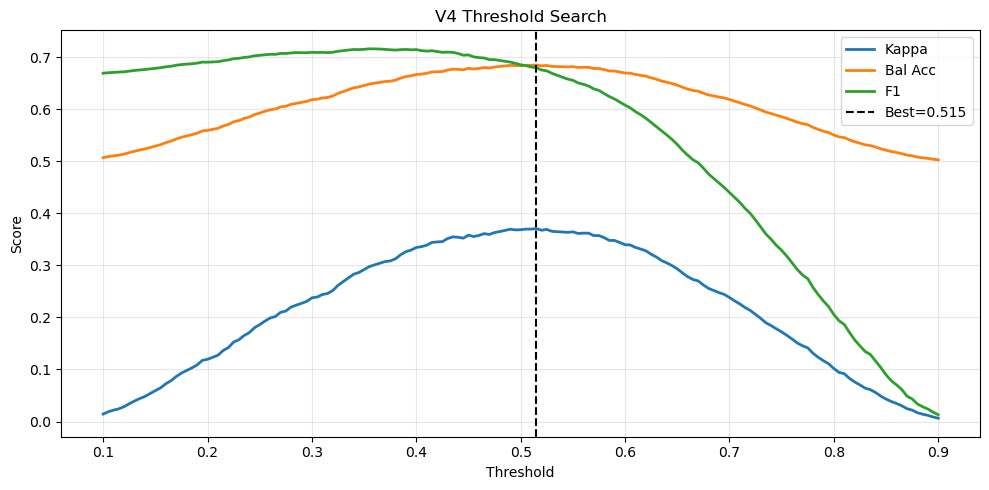

In [ ]:
# ── Threshold search ──
best_thr, best_kappa = 0.5, -999
thr_rows = []

for thr in np.linspace(0.1, 0.9, 161):
    pred = (oof_prob >= thr).astype(int)
    kappa = cohen_kappa_score(y_all, pred)
    bal_acc = balanced_accuracy_score(y_all, pred)
    f1 = f1_score(y_all, pred, zero_division=0)
    thr_rows.append({"threshold": round(thr,4), "kappa": kappa, "balanced_accuracy": bal_acc, "f1": f1})
    if kappa > best_kappa:
        best_kappa = kappa
        best_thr = thr

thr_df = pd.DataFrame(thr_rows)
thr_df.to_csv(RESULTS_DIR / "threshold_search.csv", index=False)
print(f"Best threshold: {best_thr:.3f}")
print(f"Best OOF kappa: {best_kappa:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df.threshold, thr_df.kappa, label="Kappa", lw=2)
ax.plot(thr_df.threshold, thr_df.balanced_accuracy, label="Bal Acc", lw=2)
ax.plot(thr_df.threshold, thr_df.f1, label="F1", lw=2)
ax.axvline(best_thr, color="k", ls="--", label=f"Best={best_thr:.3f}")
ax.legend(); ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("V4 Threshold Search"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_search.png", dpi=300, bbox_inches="tight")
plt.show()

{
  "kappa": 0.37093750000000003,
  "accuracy": 0.68546875,
  "balanced_accuracy": 0.6854687500000001,
  "sensitivity": 0.6690624999979092,
  "specificity": 0.7018749999978067,
  "precision": 0.6917609046849758,
  "f1": 0.6802223987291501,
  "mcc": 0.3711373482042904,
  "auc": 0.75572822265625,
  "threshold": 0.515
}


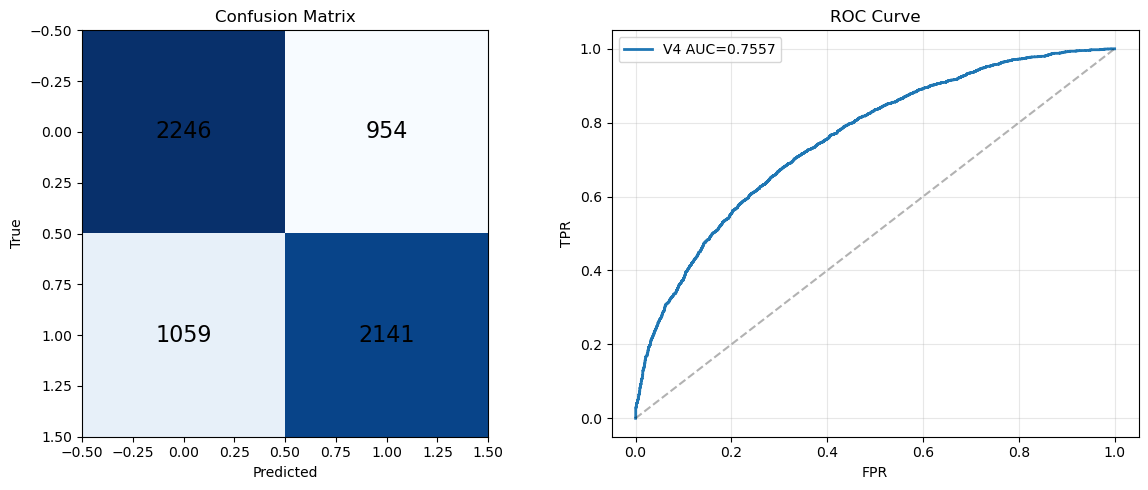

In [ ]:
# ── Final metrics ──
final_oof_pred = (oof_prob >= best_thr).astype(int)
cm = confusion_matrix(y_all, final_oof_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

val_metrics = {
    "kappa":             float(cohen_kappa_score(y_all, final_oof_pred)),
    "accuracy":          float(accuracy_score(y_all, final_oof_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_all, final_oof_pred)),
    "sensitivity":       float(tp / (tp + fn + 1e-8)),
    "specificity":       float(tn / (tn + fp + 1e-8)),
    "precision":         float(precision_score(y_all, final_oof_pred, zero_division=0)),
    "f1":                float(f1_score(y_all, final_oof_pred, zero_division=0)),
    "mcc":               float(matthews_corrcoef(y_all, final_oof_pred)),
    "auc":               float(roc_auc_score(y_all, oof_prob)),
    "threshold":         float(best_thr),
}
save_json(val_metrics, RESULTS_DIR / "val_metrics_summary.json")
print(json.dumps(val_metrics, indent=2))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# ROC
fpr, tpr, _ = roc_curve(y_all, oof_prob)
axes[1].plot(fpr, tpr, lw=2, label=f'V4 AUC={oof_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "metrics.png", dpi=300, bbox_inches="tight")
plt.show()

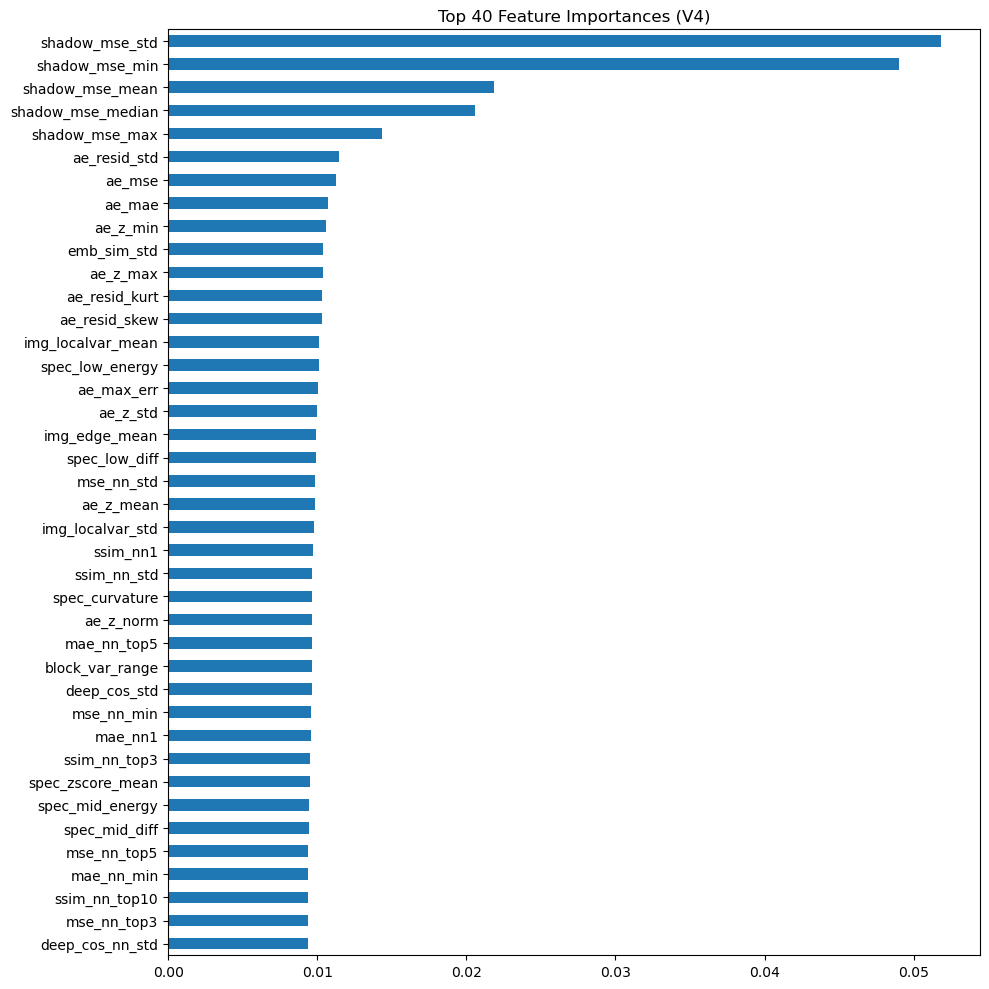


Top features by source:
  Spectral    : 0.1432 (17 features, top=spec_low_energy)
  Deep dist   : 0.1595 (19 features, top=deep_cos_std)
  Image stats : 0.1088 (13 features, top=img_localvar_mean)
  LBP         : 0.0837 (10 features, top=lbp_2)
  Block       : 0.0281 (3 features, top=block_var_range)
  AE          : 0.1145 (11 features, top=ae_resid_std)
  SSIM NN     : 0.0569 (6 features, top=ssim_nn1)
  MSE NN      : 0.0569 (6 features, top=mse_nn_std)
  Emb sim     : 0.0622 (7 features, top=emb_sim_std)
  Shadow      : 0.1576 (5 features, top=shadow_mse_std)


In [ ]:
# ── Feature importance ──
et = ExtraTreesClassifier(n_estimators=1500, min_samples_leaf=3,
                          class_weight="balanced_subsample", random_state=SEED, n_jobs=-1)
et.fit(X_all, y_all)
imp = pd.Series(et.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
imp.head(40).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 40 Feature Importances (V4)")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Show top features by signal source
print("\nTop features by source:")
for prefix, label in [("spec_", "Spectral"), ("deep_", "Deep dist"), ("img_", "Image stats"),
                       ("lbp_", "LBP"), ("block_", "Block"),
                       ("ae_", "AE"), ("ssim_", "SSIM NN"), ("mse_nn", "MSE NN"),
                       ("emb_", "Emb sim"), ("shadow_", "Shadow")]:
    cols = [c for c in imp.index if c.startswith(prefix)]
    if cols:
        total = imp[cols].sum()
        print(f"  {label:12s}: {total:.4f} ({len(cols)} features, top={imp[cols].index[0]})")

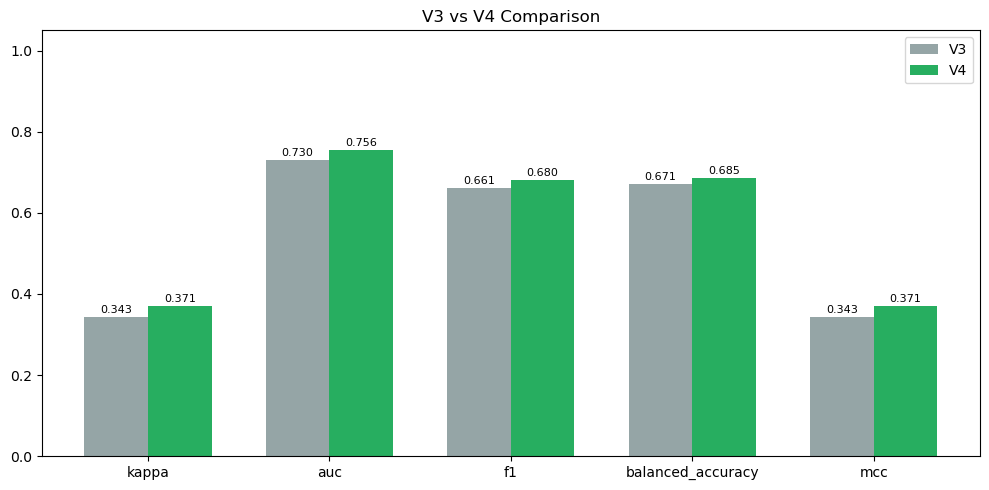

In [ ]:
# ── Visualize: V3 vs V4 improvement ──
v3_metrics_path = ROOT / "task1_v3_shadow_mia" / "results" / "val_metrics_summary.json"
if v3_metrics_path.exists():
    v3_m = json.loads(v3_metrics_path.read_text())
    metrics_compare = ["kappa", "auc", "f1", "balanced_accuracy", "mcc"]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(metrics_compare))
    w = 0.35
    v3_vals = [v3_m[m] for m in metrics_compare]
    v4_vals = [val_metrics[m] for m in metrics_compare]
    ax.bar(x - w/2, v3_vals, w, label='V3', color='#95a5a6')
    ax.bar(x + w/2, v4_vals, w, label='V4', color='#27ae60')
    ax.set_xticks(x); ax.set_xticklabels(metrics_compare)
    for i in range(len(x)):
        ax.text(i-w/2, v3_vals[i]+0.01, f'{v3_vals[i]:.3f}', ha='center', fontsize=8)
        ax.text(i+w/2, v4_vals[i]+0.01, f'{v4_vals[i]:.3f}', ha='center', fontsize=8)
    ax.legend(); ax.set_title('V3 vs V4 Comparison'); ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "v3_vs_v4.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Generate submission ──
final_test_pred = (final_test_prob >= best_thr).astype(int)

submission = pd.DataFrame({
    "image_id": test_feat["image_id"].values,
    "label": final_test_pred
})

run_csv_path = PRED_DIR / "run.csv"
submission.to_csv(run_csv_path, index=False, header=False)

zip_path = shutil.make_archive(
    str(PRED_DIR / "Method1").replace(".zip", ""),
    "zip", root_dir=PRED_DIR, base_dir="run.csv"
)

prob_df = pd.DataFrame({
    "image_id": test_feat["image_id"].values,
    "score_used": final_test_prob,
    "label": final_test_pred
})
prob_df.to_csv(PRED_DIR / "test_probabilities.csv", index=False)

print(f"Predictions: {final_test_pred.sum()} used, {len(final_test_pred)-final_test_pred.sum()} not used")
print(f"Saved: {run_csv_path}")
print(f"Zip:   {zip_path}")

Predictions: 556 used, 1584 not used
Saved: /Users/cherubim/Desktop/GAN/task1_v4_enhanced/predictions/run.csv
Zip:   /Users/cherubim/Desktop/GAN/task1_v4_enhanced/predictions/Method1.zip


In [ ]:
# ── Summary ──
summary = {
    "device": DEVICE,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "num_features": len(feature_cols),
    "oof_kappa": float(val_metrics["kappa"]),
    "oof_auc": float(val_metrics["auc"]),
    "best_threshold": float(best_thr),
    "n_classifiers": n_clfs,
    "classifier_weights": {n: round(w, 4) for n, w in weights.items()},
    "v3_auc": 0.730,
    "improvement": f"+{(val_metrics['auc'] - 0.730):.4f} AUC",
    "run_csv": str(run_csv_path),
    "submission_zip": str(zip_path)
}
save_json(summary, RESULTS_DIR / "run_summary.json")
print(json.dumps(summary, indent=2))

{
  "device": "mps",
  "train_rows": 6400,
  "test_rows": 2140,
  "num_features": 100,
  "oof_kappa": 0.37093750000000003,
  "oof_auc": 0.75572822265625,
  "best_threshold": 0.515,
  "n_classifiers": 6,
  "classifier_weights": {
    "hgb1": 0.1676,
    "hgb2": 0.1665,
    "gbm": 0.1683,
    "et": 0.1591,
    "rf": 0.1646,
    "lr": 0.174
  },
  "v3_auc": 0.73,
  "improvement": "+0.0257 AUC",
  "run_csv": "/Users/cherubim/Desktop/GAN/task1_v4_enhanced/predictions/run.csv",
  "submission_zip": "/Users/cherubim/Desktop/GAN/task1_v4_enhanced/predictions/Method1.zip"
}
